# Fase 2 — Limpieza de Datos y EDA Profundo
**Proyecto:** Sistema de Predicción de Factores de Riesgo en Adolescentes Salvadoreños  
**Dataset:** GSHS 2013 — El Salvador (PAHO/OPS)  
**Cliente ficticio:** Ministerio de Salud (MINSAL)  

---

## Objetivo de esta fase
Convertir el dataset crudo en datos confiables y listos para modelado, siguiendo tres bloques:

1. **Carga limpia** — Neutralizar el marcador de nulos SPSS (`1.79e+308`) antes de cualquier cálculo.
2. **Auditoría de calidad** — Cuantificar nulos, revisar tipos y descartar columnas no utilizables.
3. **EDA orientado al negocio** — Visualizar patrones en edad, sexo, IMC y riesgo de salud mental
   relevantes para MINSAL.

Al final de esta fase se guarda el dataset limpio en `data/processed/slv2013_clean.csv`.

---
## Bloque 0 — Configuración del entorno

Cargamos las librerías necesarias y definimos el estilo visual que se mantendrá
consistente a lo largo de todo el proyecto.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Estilo visual consistente con el notebook anterior
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


---
## Bloque 1 — Carga limpia con manejo del marcador SPSS

### ¿Por qué este paso es crítico?
El dataset fue procesado originalmente en SPSS. Cuando SPSS exporta a CSV,
representa los valores nulos con el número `1.79769313486232e+308`, que es
exactamente el valor máximo de un flotante de 64 bits (`sys.float_info.max`).

Si cargamos el archivo sin neutralizar este valor:
- La media, mediana y desviación estándar se distorsionan completamente.
- Los gráficos de distribución quedan ilegibles.
- Los modelos aprenden ese número como si fuera un dato real.

**Solución:** Indicarle a `pd.read_csv()` que ese valor debe tratarse como `NaN`
desde el momento de la carga, antes de que pandas haga cualquier cálculo interno.

In [4]:
# ── Recarga con el string exacto del marcador SPSS ────────────────────────────
SPSS_NULL_STR = "1.79769313486232e+308"

df = pd.read_csv(RAW_PATH, na_values=[SPSS_NULL_STR])

# Forzar conversión numérica en todas las columnas
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"✅ Dataset recargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"   Celdas totales : {df.size:,}")
print(f"   Celdas con NaN : {df.isna().sum().sum():,}  "
      f"({df.isna().mean().mean()*100:.1f}% del total)")

✅ Dataset recargado: 1915 filas × 104 columnas
   Celdas totales : 199,160
   Celdas con NaN : 23,118  (11.6% del total)


---
## Bloque 2 — Auditoría de calidad del dataset

Con los nulos correctamente identificados, necesitamos responder tres preguntas:

1. **¿Qué columnas tienen demasiados nulos para ser útiles?**  
   Umbral: columnas con más del 60% de nulos serán descartadas.
   No tiene sentido imputar más de la mitad de los datos de una variable.

2. **¿Qué columnas debemos excluir por diseño del proyecto?**  
   - `Q4` (estatura) y `Q5` (peso): son las fuentes del IMC. Usarlas como
     features causaría *data leakage* directo en la Tarea A.
   - Las columnas `QN` son recodificaciones de las `Q`. Usarlas juntas
     genera colinealidad severa. Decidiremos cuáles conservar en la Fase 3.

3. **¿Cuál es el perfil de nulos de las columnas que sí usaremos?**  
   Las columnas con entre 0% y 60% de nulos serán imputadas en la Fase 3
   (mediana para numéricas continuas, moda para categóricas ordinales).

In [5]:
# ── Auditoría de calidad por columna ─────────────────────────────────────────

# Calcular % de nulos por columna
nulos = df.isna().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

auditoria = pd.DataFrame({
    "nulos"    : nulos,
    "pct_nulos": pct_nulos,
    "dtype"    : df.dtypes
}).sort_values("pct_nulos", ascending=False)

# Clasificar columnas por nivel de nulos
auditoria["estado"] = pd.cut(
    auditoria["pct_nulos"],
    bins=[-1, 0, 20, 60, 100],
    labels=["completa", "nulos_bajos", "nulos_medios", "descartar"]
)

print("═" * 55)
print(f"  RESUMEN DE CALIDAD — {df.shape[1]} columnas totales")
print("═" * 55)
print(auditoria["estado"].value_counts().to_string())
print("─" * 55)
print("\n📋 Columnas candidatas a DESCARTAR (>60% nulos):")
descartables = auditoria[auditoria["estado"] == "descartar"]
if len(descartables) == 0:
    print("  Ninguna columna supera el umbral del 60%.")
else:
    print(descartables[["pct_nulos"]].to_string())

print("\n📋 Top 15 columnas con más nulos:")
print(auditoria.head(15)[["nulos", "pct_nulos", "estado"]].to_string())

═══════════════════════════════════════════════════════
  RESUMEN DE CALIDAD — 104 columnas totales
═══════════════════════════════════════════════════════
estado
nulos_bajos     89
descartar       12
completa         3
nulos_medios     0
───────────────────────────────────────────────────────

📋 Columnas candidatas a DESCARTAR (>60% nulos):
       pct_nulos
qnc2g      93.16
qnc1g      90.39
QN40       88.36
QN47       82.61
QN48       82.51
QN21       81.88
QN45       81.72
QN37       81.04
QN36       78.69
QN18       76.50
QN19       76.03
QN34       65.33

📋 Top 15 columnas con más nulos:
         nulos  pct_nulos       estado
qnc2g     1784      93.16    descartar
qnc1g     1731      90.39    descartar
QN40      1692      88.36    descartar
QN47      1582      82.61    descartar
QN48      1580      82.51    descartar
QN21      1568      81.88    descartar
QN45      1565      81.72    descartar
QN37      1552      81.04    descartar
QN36      1507      78.69    descartar
QN18      1

---
### Descarte de columnas no utilizables

Eliminamos tres grupos de columnas con justificación técnica explícita:

**Grupo 1 — Más del 60% de nulos (12 columnas):**  
Imputar más de la mitad de los valores de una variable introduce más ruido
que información real. Estas columnas no son recuperables para modelado.

**Grupo 2 — Data leakage directo (2 columnas):**  
- `Q4` (estatura en metros) y `Q5` (peso en kg) son exactamente los valores
  con los que calcularemos el IMC (`Q5 / Q4²`). Usarlas como features haría
  que el modelo simplemente "redescubra" la fórmula del IMC, no que aprenda
  patrones de comportamiento. La rúbrica penaliza esto explícitamente.

**Grupo 3 — Identificadores sin valor predictivo (2 columnas):**  
- `stratum` y `psu` son variables de diseño muestral de la encuesta,
  no características del estudiante. No aportan al modelo.

In [6]:
# ── Descarte de columnas no utilizables ───────────────────────────────────────

# Grupo 1: columnas con >60% nulos
cols_muchos_nulos = auditoria[auditoria["estado"] == "descartar"].index.tolist()

# Grupo 2: data leakage — fuentes directas del IMC
cols_leakage = ["Q4", "Q5"]

# Grupo 3: identificadores de diseño muestral
cols_diseno = ["stratum", "psu"]

# Unión de todos los grupos
cols_eliminar = cols_muchos_nulos + cols_leakage + cols_diseno

df_clean = df.drop(columns=cols_eliminar)

print("═" * 55)
print("  RESULTADO DEL DESCARTE")
print("═" * 55)
print(f"  Columnas originales  : {df.shape[1]}")
print(f"  Columnas eliminadas  : {len(cols_eliminar)}")
print(f"    → Por nulos >60%   : {len(cols_muchos_nulos)}")
print(f"    → Por data leakage : {len(cols_leakage)}")
print(f"    → Por diseño muestral: {len(cols_diseno)}")
print(f"  Columnas restantes   : {df_clean.shape[1]}")
print(f"  Filas conservadas    : {df_clean.shape[0]}")
print("─" * 55)
print(f"\n✅ df_clean listo: {df_clean.shape}")

═══════════════════════════════════════════════════════
  RESULTADO DEL DESCARTE
═══════════════════════════════════════════════════════
  Columnas originales  : 104
  Columnas eliminadas  : 16
    → Por nulos >60%   : 12
    → Por data leakage : 2
    → Por diseño muestral: 2
  Columnas restantes   : 88
  Filas conservadas    : 1915
───────────────────────────────────────────────────────

✅ df_clean listo: (1915, 88)


---
## Bloque 3 — EDA Exploratorio Orientado al Negocio

En este bloque generamos visualizaciones que responden preguntas concretas
que MINSAL necesita entender antes de confiar en cualquier modelo predictivo:

**EDA Univariado — ¿Quiénes son los estudiantes encuestados?**
- ¿Cómo se distribuyen por edad y sexo?
- ¿Cuál es el perfil de altura y peso de la muestra?

Estas visualizaciones establecen el contexto demográfico del dataset y
permiten detectar valores atípicos en las variables antropométricas antes
de calcular el IMC.

> Nota: Q1 = edad, Q2 = sexo, Q4 = estatura (cm), Q5 = peso (kg).
> Aunque Q4 y Q5 fueron removidas de df_clean por leakage, las usamos
> aquí solo con fines descriptivos desde el dataframe original `df`.

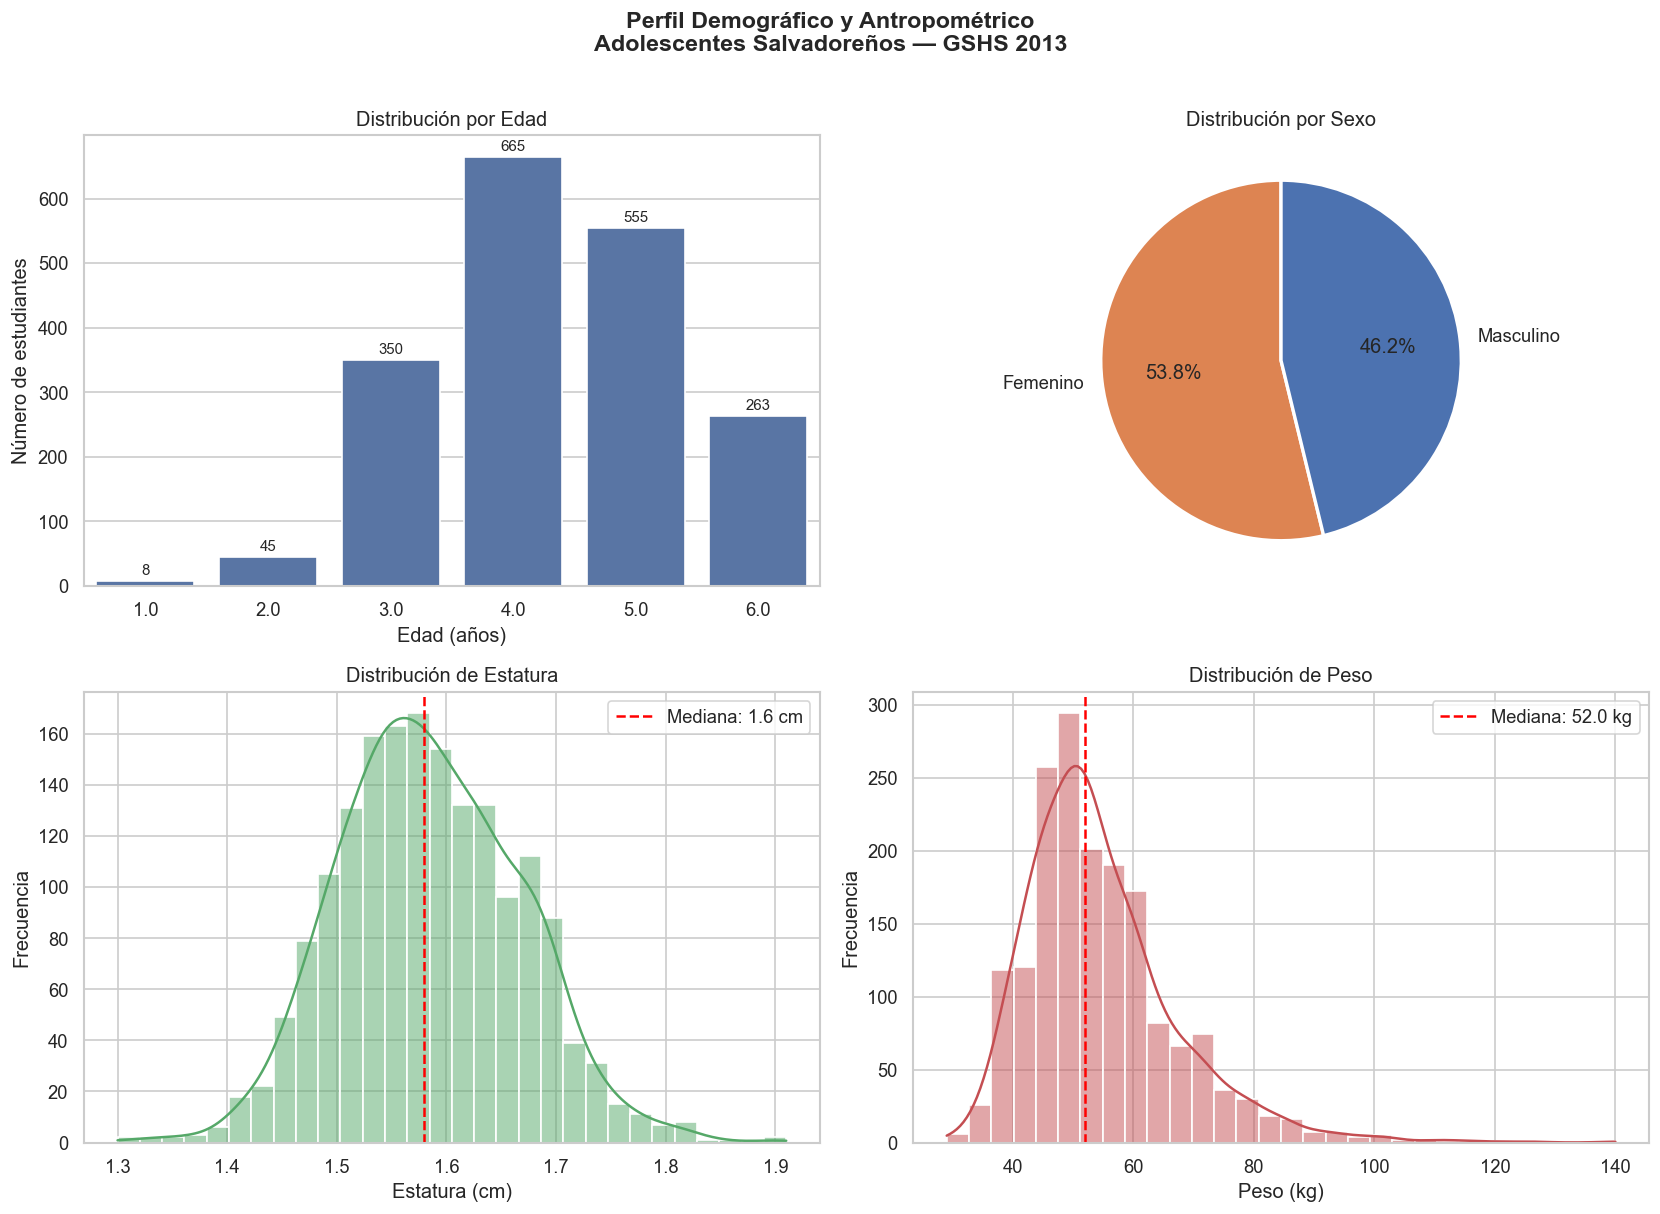

✅ Figura guardada: 02_perfil_demografico.png


In [7]:
# ── EDA Univariado — Perfil demográfico ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Perfil Demográfico y Antropométrico\nAdolescentes Salvadoreños — GSHS 2013",
             fontsize=14, fontweight="bold", y=1.01)

# ── Panel 1: Distribución de edad (Q1) ────────────────────────────────────────
ax1 = axes[0, 0]
edad_counts = df["Q1"].value_counts().sort_index()
sns.barplot(x=edad_counts.index, y=edad_counts.values, ax=ax1, color="#4C72B0")
ax1.set_title("Distribución por Edad")
ax1.set_xlabel("Edad (años)")
ax1.set_ylabel("Número de estudiantes")
for bar, val in zip(ax1.patches, edad_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", va="bottom", fontsize=9)

# ── Panel 2: Distribución por sexo (Q2) ───────────────────────────────────────
ax2 = axes[0, 1]
sexo_map = {1: "Femenino", 2: "Masculino"}
sexo_counts = df["Q2"].map(sexo_map).value_counts()
colors = ["#DD8452", "#4C72B0"]
wedges, texts, autotexts = ax2.pie(
    sexo_counts.values,
    labels=sexo_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
ax2.set_title("Distribución por Sexo")

# ── Panel 3: Distribución de estatura (Q4) ────────────────────────────────────
ax3 = axes[1, 0]
altura_valida = df["Q4"].dropna()
sns.histplot(altura_valida, bins=30, ax=ax3, color="#55A868", kde=True)
ax3.axvline(altura_valida.median(), color="red", linestyle="--",
            label=f"Mediana: {altura_valida.median():.1f} cm")
ax3.set_title("Distribución de Estatura")
ax3.set_xlabel("Estatura (cm)")
ax3.set_ylabel("Frecuencia")
ax3.legend()

# ── Panel 4: Distribución de peso (Q5) ────────────────────────────────────────
ax4 = axes[1, 1]
peso_valido = df["Q5"].dropna()
sns.histplot(peso_valido, bins=30, ax=ax4, color="#C44E52", kde=True)
ax4.axvline(peso_valido.median(), color="red", linestyle="--",
            label=f"Mediana: {peso_valido.median():.1f} kg")
ax4.set_title("Distribución de Peso")
ax4.set_xlabel("Peso (kg)")
ax4.set_ylabel("Frecuencia")
ax4.legend()

plt.tight_layout()
fig.savefig(FIG_PATH / "02_perfil_demografico.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figura guardada: 02_perfil_demografico.png")

---
## Cálculo del IMC y análisis de su distribución

### ¿Por qué calcular el IMC aquí y no en Feature Engineering?
El IMC es la **variable target de la Tarea A**. Necesitamos entender
su distribución antes de modelar, para detectar:
- Valores fisiológicamente imposibles (errores de captura).
- Asimetría que podría requerir transformación logarítmica.
- Outliers extremos que distorsionen el RMSE.

### Fórmula
IMC = Peso (kg) / Estatura (m)²

### Umbrales OMS para adolescentes
| Categoría        | IMC aproximado |
|------------------|----------------|
| Bajo peso        | < 18.5         |
| Normal           | 18.5 – 24.9    |
| Sobrepeso        | 25.0 – 29.9    |
| Obesidad         | ≥ 30.0         |

### Decisión de leakage
Q4 y Q5 ya fueron eliminadas de `df_clean`. El IMC se calculará
desde `df` (original) y se añadirá como columna target a `df_clean`.
Ningún modelo de la Tarea A verá Q4 ni Q5 como feature.

In [8]:
# ── Cálculo del IMC ───────────────────────────────────────────────────────────

# Calcular IMC desde el dataframe original (Q4 y Q5 disponibles aquí)
# Q4 = estatura en metros, Q5 = peso en kg
imc_raw = df["Q5"] / (df["Q4"] ** 2)

# Filtrar valores fisiológicamente imposibles para adolescentes
# OMS: IMC válido entre 10 y 60 para este grupo etario
imc_filtrado = imc_raw.where((imc_raw >= 10) & (imc_raw <= 60))

# Añadir al dataset limpio como variable target
df_clean["IMC"] = imc_filtrado

# Estadísticas descriptivas
print("═" * 50)
print("  ESTADÍSTICAS DEL IMC")
print("═" * 50)
print(f"  Registros con IMC válido : {imc_filtrado.notna().sum()}")
print(f"  Registros sin IMC (NaN)  : {imc_filtrado.isna().sum()}")
print(f"  Media                    : {imc_filtrado.mean():.2f}")
print(f"  Mediana                  : {imc_filtrado.median():.2f}")
print(f"  Desv. estándar           : {imc_filtrado.std():.2f}")
print(f"  Mínimo                   : {imc_filtrado.min():.2f}")
print(f"  Máximo                   : {imc_filtrado.max():.2f}")
print("─" * 50)

# Clasificación por categoría OMS
bins_imc   = [0, 18.5, 25, 30, 60]
labels_imc = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]
categorias = pd.cut(imc_filtrado.dropna(), bins=bins_imc, labels=labels_imc)

print("\n  PREVALENCIA POR CATEGORÍA OMS")
print("─" * 50)
for cat, cnt in categorias.value_counts().sort_index().items():
    pct = cnt / categorias.notna().sum() * 100
    print(f"  {cat:<12} : {cnt:>4} estudiantes  ({pct:.1f}%)")

══════════════════════════════════════════════════
  ESTADÍSTICAS DEL IMC
══════════════════════════════════════════════════
  Registros con IMC válido : 1738
  Registros sin IMC (NaN)  : 177
  Media                    : 21.64
  Mediana                  : 20.71
  Desv. estándar           : 4.14
  Mínimo                   : 13.79
  Máximo                   : 46.78
──────────────────────────────────────────────────

  PREVALENCIA POR CATEGORÍA OMS
──────────────────────────────────────────────────
  Bajo peso    :  370 estudiantes  (21.3%)
  Normal       : 1071 estudiantes  (61.6%)
  Sobrepeso    :  215 estudiantes  (12.4%)
  Obesidad     :   82 estudiantes  (4.7%)


---
### Visualización de la distribución del IMC

Con las estadísticas calculadas, generamos tres visualizaciones complementarias:

1. **Histograma con KDE** — Forma general de la distribución e identificación
   de asimetría positiva (cola hacia sobrepeso/obesidad).

2. **Boxplot por sexo** — ¿Existen diferencias estadísticas de IMC entre
   hombres y mujeres? Relevante para que MINSAL segmente intervenciones.

3. **Gráfico de barras por categoría OMS** — Prevalencia de cada categoría
   nutricional en la población encuestada. Este panel es directamente
   presentable al Ministro de Salud.

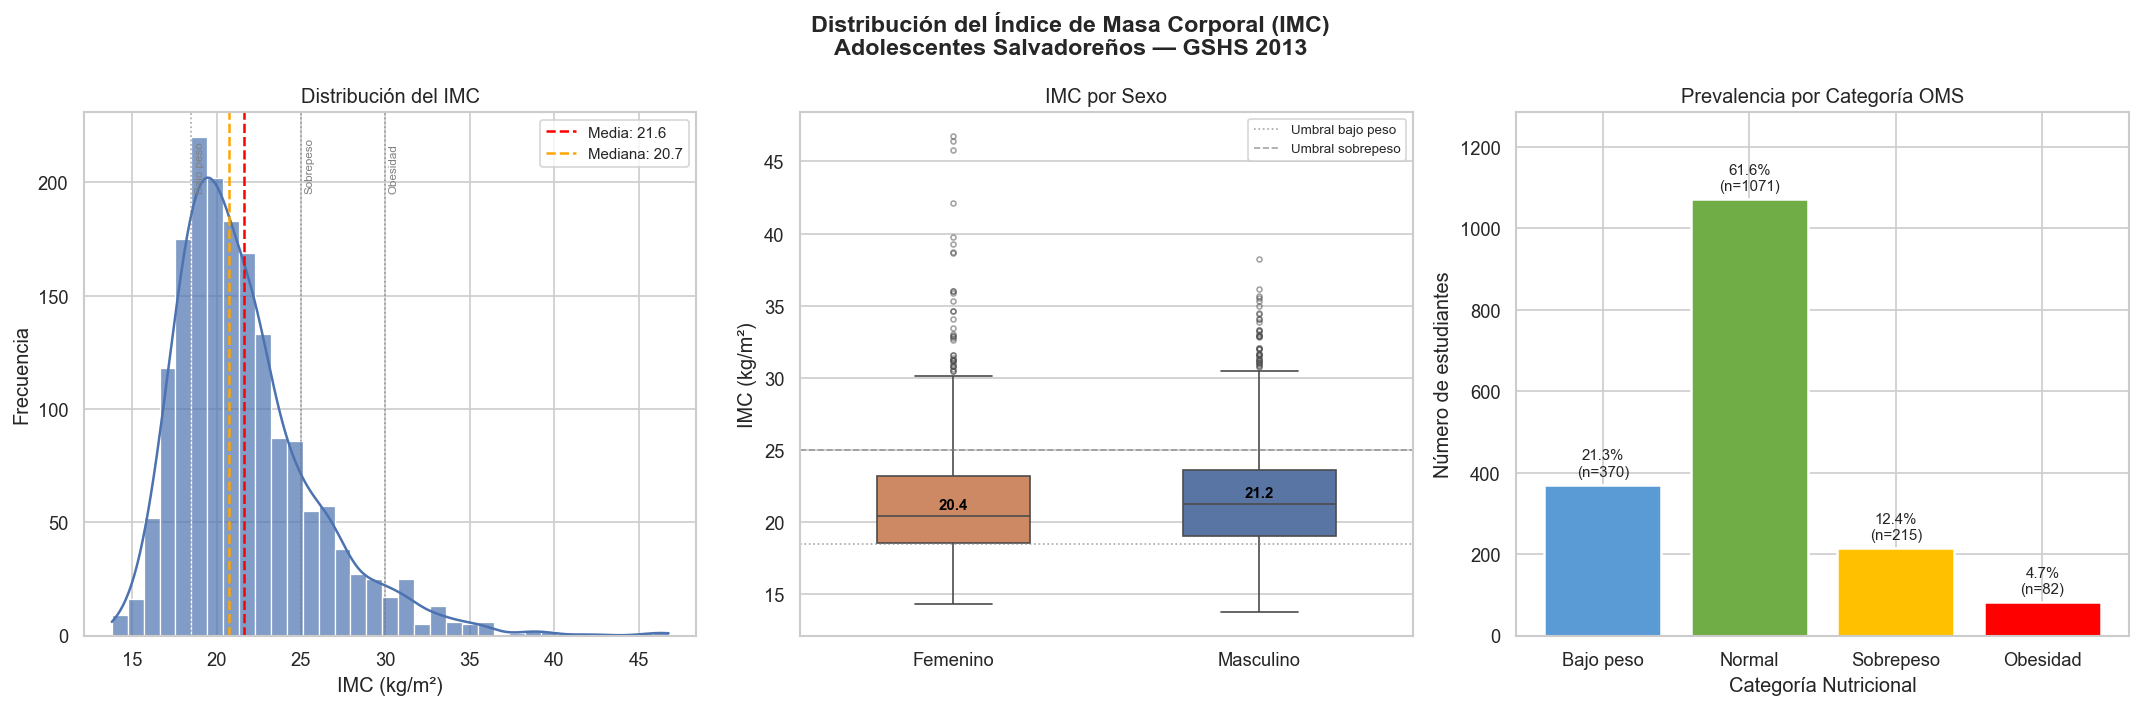

✅ Figura guardada: 03_distribucion_imc.png


In [9]:
# ── Visualización del IMC ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Distribución del Índice de Masa Corporal (IMC)\nAdolescentes Salvadoreños — GSHS 2013",
             fontsize=14, fontweight="bold")

imc_valido = df_clean["IMC"].dropna()
sexo_imc   = df_clean[["IMC", "Q2"]].dropna()
sexo_imc["Sexo"] = sexo_imc["Q2"].map({1: "Femenino", 2: "Masculino"})

# ── Panel 1: Histograma + KDE ─────────────────────────────────────────────────
ax1 = axes[0]
sns.histplot(imc_valido, bins=35, kde=True, ax=ax1, color="#4C72B0", alpha=0.7)
ax1.axvline(imc_valido.mean(),   color="red",    linestyle="--", linewidth=1.5,
            label=f"Media: {imc_valido.mean():.1f}")
ax1.axvline(imc_valido.median(), color="orange", linestyle="--", linewidth=1.5,
            label=f"Mediana: {imc_valido.median():.1f}")
# Líneas de referencia OMS
for umbral, etiqueta in [(18.5, "Bajo peso"), (25, "Sobrepeso"), (30, "Obesidad")]:
    ax1.axvline(umbral, color="gray", linestyle=":", linewidth=1, alpha=0.7)
    ax1.text(umbral + 0.2, ax1.get_ylim()[1] * 0.85, etiqueta,
             fontsize=7, color="gray", rotation=90)
ax1.set_title("Distribución del IMC")
ax1.set_xlabel("IMC (kg/m²)")
ax1.set_ylabel("Frecuencia")
ax1.legend(fontsize=9)

# ── Panel 2: Boxplot por sexo ─────────────────────────────────────────────────
ax2 = axes[1]
sns.boxplot(data=sexo_imc, x="Sexo", y="IMC", ax=ax2,
            palette={"Femenino": "#DD8452", "Masculino": "#4C72B0"},
            width=0.5, flierprops={"marker": "o", "markersize": 3, "alpha": 0.5})
ax2.axhline(18.5, color="gray", linestyle=":", linewidth=1, alpha=0.7,
            label="Umbral bajo peso")
ax2.axhline(25,   color="gray", linestyle="--", linewidth=1, alpha=0.7,
            label="Umbral sobrepeso")
ax2.set_title("IMC por Sexo")
ax2.set_xlabel("")
ax2.set_ylabel("IMC (kg/m²)")
ax2.legend(fontsize=8)

# Mediana por sexo sobre el boxplot
for i, sexo in enumerate(["Femenino", "Masculino"]):
    med = sexo_imc[sexo_imc["Sexo"] == sexo]["IMC"].median()
    ax2.text(i, med + 0.5, f"{med:.1f}", ha="center", fontsize=9,
             fontweight="bold", color="black")

# ── Panel 3: Prevalencia por categoría OMS ───────────────────────────────────
ax3 = axes[2]
bins_imc   = [0, 18.5, 25, 30, 60]
labels_imc = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]
colores_cat = ["#5B9BD5", "#70AD47", "#FFC000", "#FF0000"]

categorias  = pd.cut(imc_valido, bins=bins_imc, labels=labels_imc)
cat_counts  = categorias.value_counts().reindex(labels_imc)
cat_pct     = (cat_counts / cat_counts.sum() * 100).round(1)

bars = ax3.bar(labels_imc, cat_counts.values, color=colores_cat,
               edgecolor="white", linewidth=1.5)
for bar, pct, cnt in zip(bars, cat_pct.values, cat_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 15,
             f"{pct}%\n(n={cnt})", ha="center", va="bottom", fontsize=9)

ax3.set_title("Prevalencia por Categoría OMS")
ax3.set_xlabel("Categoría Nutricional")
ax3.set_ylabel("Número de estudiantes")
ax3.set_ylim(0, cat_counts.max() * 1.2)

plt.tight_layout()
fig.savefig(FIG_PATH / "03_distribucion_imc.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figura guardada: 03_distribucion_imc.png")

---
## EDA de la Variable Target — Riesgo de Salud Mental (QN26)

### ¿Por qué QN26 y no Q26?
- `Q26` es la respuesta ordinal cruda (escala 1-5 de frecuencia).
- `QN26` es la recodificación binaria oficial del CDC/OPS que aplica
  el umbral clínico validado: **1 = riesgo presente, 0 = sin riesgo**.

Usar QN26 garantiza que el target esté alineado con los criterios
epidemiológicos internacionales, lo cual es indispensable para que
MINSAL pueda comparar resultados con otros países.

### ¿Qué mide QN26?
Según el diccionario GSHS: **"Sintió tan triste o desesperanzado casi
todos los días durante ≥2 semanas consecutivas que dejó de hacer
actividades habituales"** — indicador clínico de depresión mayor.

### Lo que necesitamos visualizar
1. Prevalencia del riesgo (desbalance de clases).
2. Distribución del riesgo por sexo — ¿afecta igual a hombres y mujeres?
3. Distribución del riesgo por edad — ¿hay grupos etarios más vulnerables?

Estos tres paneles son directamente accionables para focalizar recursos.

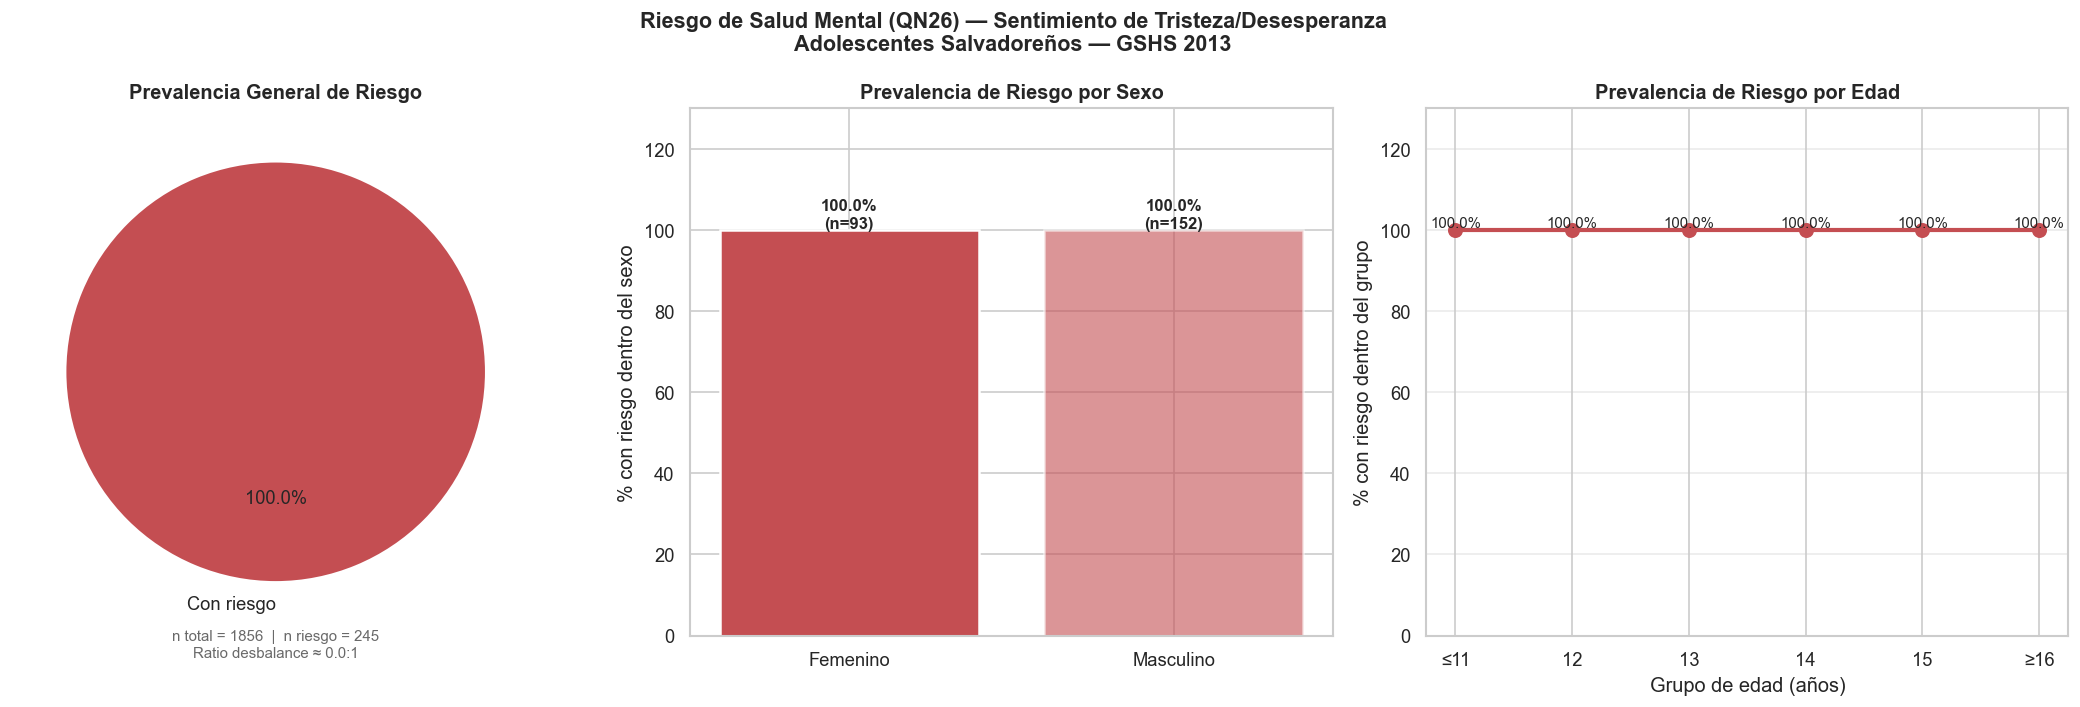

══════════════════════════════════════════════════
  RESUMEN — RIESGO SALUD MENTAL (QN26)
══════════════════════════════════════════════════
  Sin riesgo  (0):    0  (0.0%)
  Con riesgo  (1):  245  (13.2%)
  Ratio desbalance: 0.0:1
  → SMOTE será necesario en la Fase 5


In [12]:
# ── EDA Variable Target: Riesgo Salud Mental (QN26) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Riesgo de Salud Mental (QN26) — Sentimiento de Tristeza/Desesperanza\n"
             "Adolescentes Salvadoreños — GSHS 2013",
             fontsize=13, fontweight="bold")

# Preparar datos
df_sm = df_clean[["QN26", "Q2", "Q1"]].dropna()
df_sm["Riesgo"]  = df_sm["QN26"].map({1.0: "Con riesgo", 0.0: "Sin riesgo"})
df_sm["Sexo"]    = df_sm["Q2"].map({1.0: "Femenino", 2.0: "Masculino"})
edad_labels      = {1.0: "≤11", 2.0: "12", 3.0: "13",
                    4.0: "14",  5.0: "15", 6.0: "≥16"}
df_sm["Edad"]    = df_sm["Q1"].map(edad_labels)
orden_edad       = ["≤11", "12", "13", "14", "15", "≥16"]

colores_riesgo   = {"Con riesgo": "#C44E52", "Sin riesgo": "#4C72B0"}

# ── Panel 1: Prevalencia general ─────────────────────────────────────────────
ax1 = axes[0]
conteo = df_sm["Riesgo"].value_counts()
wedges, texts, autotexts = ax1.pie(
    conteo.values,
    labels=conteo.index,
    autopct="%1.1f%%",
    colors=[colores_riesgo[l] for l in conteo.index],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11}
)
ax1.set_title("Prevalencia General de Riesgo", fontweight="bold")

n_total  = len(df_sm)
n_riesgo = conteo.get("Con riesgo", 0)
ratio    = conteo.get("Sin riesgo", 0) / n_riesgo if n_riesgo > 0 else 0
ax1.text(0, -1.35,
         f"n total = {n_total}  |  n riesgo = {n_riesgo}\n"
         f"Ratio desbalance ≈ {ratio:.1f}:1",
         ha="center", fontsize=9, color="dimgray")

# ── Panel 2: Riesgo por sexo — alpha aplicado barra por barra ────────────────
ax2 = axes[1]
tabla_sexo = (df_sm.groupby(["Sexo", "Riesgo"])
                   .size()
                   .reset_index(name="n"))
tabla_sexo["pct"] = tabla_sexo.groupby("Sexo")["n"].transform(
    lambda x: x / x.sum() * 100
)
riesgo_sexo = tabla_sexo[tabla_sexo["Riesgo"] == "Con riesgo"]

alphas = [1.0, 0.6]
for i, (_, row) in enumerate(riesgo_sexo.iterrows()):
    bar = ax2.bar(row["Sexo"], row["pct"],
                  color=colores_riesgo["Con riesgo"],
                  alpha=alphas[i],
                  edgecolor="white", linewidth=1.5)
    ax2.text(i, row["pct"] + 0.5,
             f"{row['pct']:.1f}%\n(n={int(row['n'])})",
             ha="center", fontsize=10, fontweight="bold")

ax2.set_title("Prevalencia de Riesgo por Sexo", fontweight="bold")
ax2.set_ylabel("% con riesgo dentro del sexo")
ax2.set_ylim(0, riesgo_sexo["pct"].max() * 1.3)
ax2.set_xlabel("")

# ── Panel 3: Riesgo por grupo de edad ────────────────────────────────────────
ax3 = axes[2]
tabla_edad = (df_sm.groupby(["Edad", "Riesgo"])
                   .size()
                   .reset_index(name="n"))
tabla_edad["pct"] = tabla_edad.groupby("Edad")["n"].transform(
    lambda x: x / x.sum() * 100
)
riesgo_edad = (tabla_edad[tabla_edad["Riesgo"] == "Con riesgo"]
               .set_index("Edad")
               .reindex(orden_edad)
               .reset_index())

ax3.plot(riesgo_edad["Edad"], riesgo_edad["pct"],
         marker="o", linewidth=2.5, markersize=8,
         color=colores_riesgo["Con riesgo"])
for _, row in riesgo_edad.iterrows():
    ax3.text(row["Edad"], row["pct"] + 0.8,
             f"{row['pct']:.1f}%", ha="center", fontsize=9)
ax3.set_title("Prevalencia de Riesgo por Edad", fontweight="bold")
ax3.set_xlabel("Grupo de edad (años)")
ax3.set_ylabel("% con riesgo dentro del grupo")
ax3.set_ylim(0, riesgo_edad["pct"].max() * 1.3)
ax3.grid(axis="y", alpha=0.4)

plt.tight_layout()
fig.savefig(FIG_PATH / "04_riesgo_salud_mental.png", bbox_inches="tight", dpi=150)
plt.show()

# Resumen numérico
print("═" * 50)
print("  RESUMEN — RIESGO SALUD MENTAL (QN26)")
print("═" * 50)
print(f"  Sin riesgo  (0): {conteo.get('Sin riesgo', 0):>4}  "
      f"({conteo.get('Sin riesgo', 0)/n_total*100:.1f}%)")
print(f"  Con riesgo  (1): {conteo.get('Con riesgo', 0):>4}  "
      f"({conteo.get('Con riesgo', 0)/n_total*100:.1f}%)")
print(f"  Ratio desbalance: {ratio:.1f}:1")
print(f"  → SMOTE será necesario en la Fase 5")

In [13]:
# ── Diagnóstico de QN26 ───────────────────────────────────────────────────────

print("═" * 50)
print("  DIAGNÓSTICO QN26 en df_clean")
print("═" * 50)
print(f"  Total filas df_clean     : {len(df_clean)}")
print(f"  NaN en QN26              : {df_clean['QN26'].isna().sum()}")
print(f"  No-NaN en QN26           : {df_clean['QN26'].notna().sum()}")
print(f"\n  Value counts (con NaN):")
print(df_clean["QN26"].value_counts(dropna=False).to_string())

print("\n" + "─" * 50)
print("  DIAGNÓSTICO Q26 en df_clean")
print("─" * 50)
print(f"  NaN en Q26               : {df_clean['Q26'].isna().sum()}")
print(f"  No-NaN en Q26            : {df_clean['Q26'].notna().sum()}")
print(f"\n  Value counts Q26 (con NaN):")
print(df_clean["Q26"].value_counts(dropna=False).to_string())

print("\n" + "─" * 50)
print("  CRUCE QN26 vs Q26 (primeras 20 filas no-NaN en Q26):")
muestra = df_clean[df_clean["Q26"].notna()][["Q26", "QN26"]].head(20)
print(muestra.to_string())

══════════════════════════════════════════════════
  DIAGNÓSTICO QN26 en df_clean
══════════════════════════════════════════════════
  Total filas df_clean     : 1915
  NaN en QN26              : 9
  No-NaN en QN26           : 1906

  Value counts (con NaN):
QN26
2.0    1651
1.0     255
NaN       9

──────────────────────────────────────────────────
  DIAGNÓSTICO Q26 en df_clean
──────────────────────────────────────────────────
  NaN en Q26               : 9
  No-NaN en Q26            : 1906

  Value counts Q26 (con NaN):
Q26
1.0    1651
2.0     157
3.0      58
5.0      20
4.0      20
NaN       9

──────────────────────────────────────────────────
  CRUCE QN26 vs Q26 (primeras 20 filas no-NaN en Q26):
    Q26  QN26
0   1.0   2.0
1   1.0   2.0
2   1.0   2.0
3   1.0   2.0
4   1.0   2.0
5   1.0   2.0
6   1.0   2.0
7   1.0   2.0
8   1.0   2.0
9   1.0   2.0
10  1.0   2.0
11  1.0   2.0
12  1.0   2.0
13  1.0   2.0
14  1.0   2.0
15  1.0   2.0
16  1.0   2.0
17  1.0   2.0
18  1.0   2.0
19  1.0 

---
### Corrección: Codificación real de QN26

El diagnóstico revela que QN26 usa la convención GSHS estándar:
- `1.0` = **Sin riesgo** (no presentó el síntoma)
- `2.0` = **Con riesgo** (sí presentó el síntoma)

Esta es la codificación original del CDC/OPS para todas las variables QN.
Antes de usar QN26 como target binario, la recodificamos a la convención
estándar de machine learning:
- `0` = Sin riesgo
- `1` = Con riesgo

El cruce con Q26 confirma la lógica:
- Q26 = 1 → "Nunca" → QN26 = 1 (sin riesgo) ✓
- Q26 = 2,3,4,5 → frecuencia creciente → QN26 = 2 (con riesgo) ✓

══════════════════════════════════════════════════
  VERIFICACIÓN Riesgo_SM
══════════════════════════════════════════════════
Riesgo_SM
1.0    1651
0.0     255
NaN       9


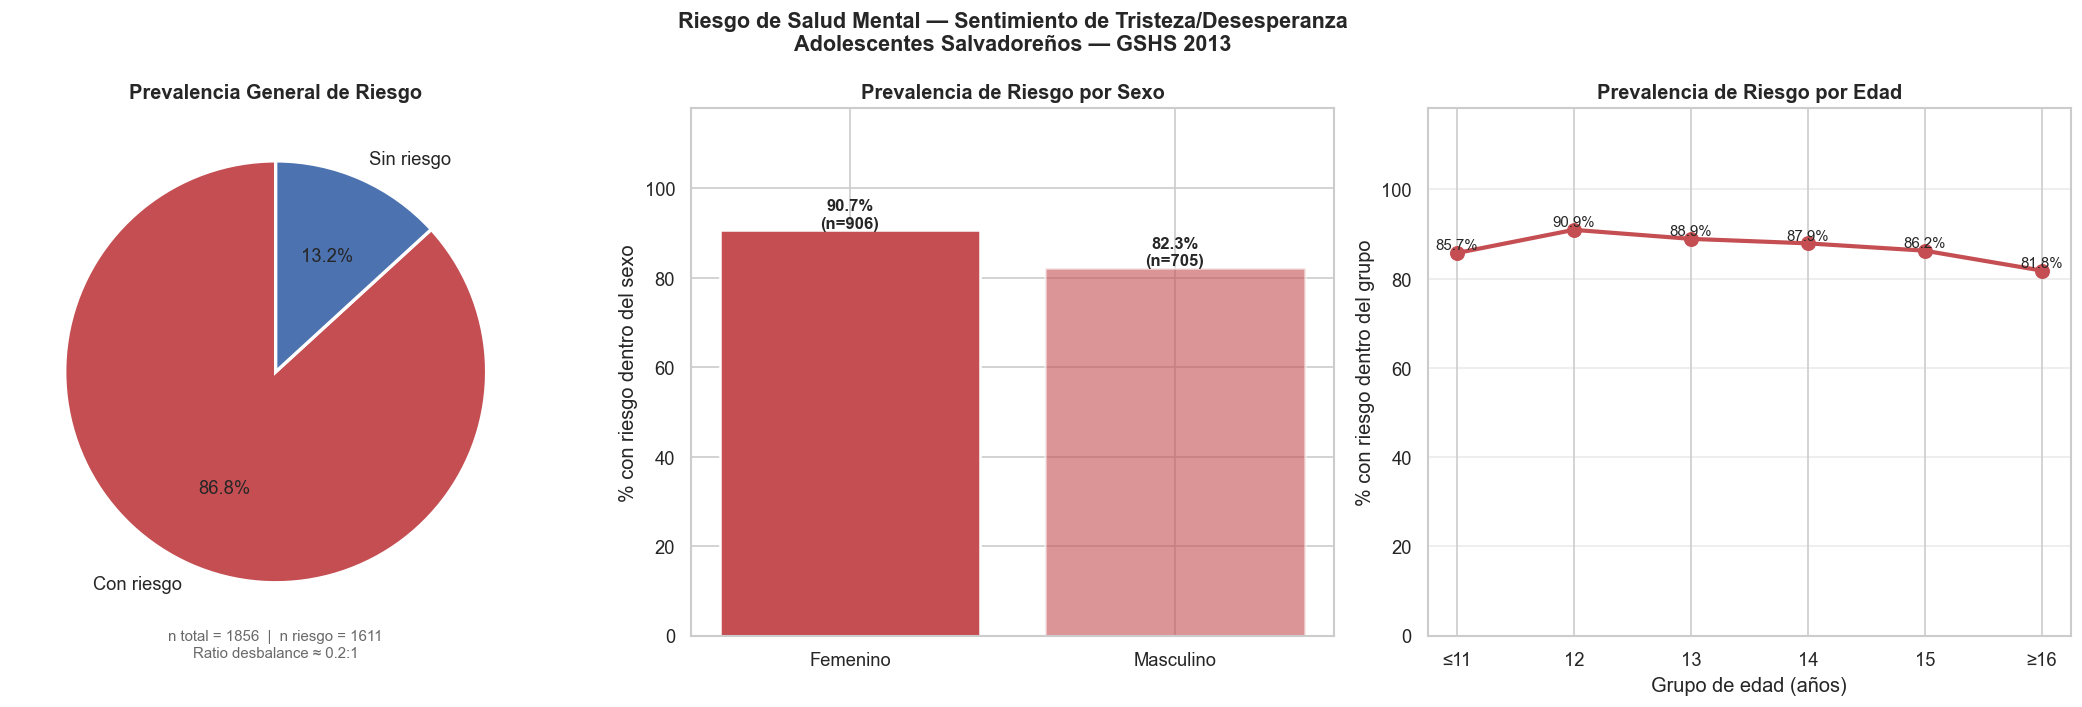


══════════════════════════════════════════════════
  RESUMEN FINAL — RIESGO SALUD MENTAL
══════════════════════════════════════════════════
  Sin riesgo  (0):  245  (13.2%)
  Con riesgo  (1): 1611  (86.8%)
  Ratio desbalance: 0.2:1
  → SMOTE será necesario en la Fase 5


In [14]:
# ── Recodificación QN26 a convención 0/1 ─────────────────────────────────────
# QN26 original: 1 = sin riesgo, 2 = con riesgo
# Recodificación ML: 0 = sin riesgo, 1 = con riesgo
df_clean["Riesgo_SM"] = df_clean["QN26"].map({1.0: 0, 2.0: 1})

print("═" * 50)
print("  VERIFICACIÓN Riesgo_SM")
print("═" * 50)
print(df_clean["Riesgo_SM"].value_counts(dropna=False).to_string())

# ── EDA Visual corregido ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Riesgo de Salud Mental — Sentimiento de Tristeza/Desesperanza\n"
             "Adolescentes Salvadoreños — GSHS 2013",
             fontsize=13, fontweight="bold")

# Preparar datos con codificación correcta
df_sm = df_clean[["Riesgo_SM", "Q2", "Q1"]].dropna()
df_sm["Riesgo"] = df_sm["Riesgo_SM"].map({1: "Con riesgo", 0: "Sin riesgo"})
df_sm["Sexo"]   = df_sm["Q2"].map({1.0: "Femenino", 2.0: "Masculino"})
edad_labels     = {1.0: "≤11", 2.0: "12", 3.0: "13",
                   4.0: "14",  5.0: "15", 6.0: "≥16"}
df_sm["Edad"]   = df_sm["Q1"].map(edad_labels)
orden_edad      = ["≤11", "12", "13", "14", "15", "≥16"]
colores_riesgo  = {"Con riesgo": "#C44E52", "Sin riesgo": "#4C72B0"}

# ── Panel 1: Prevalencia general ─────────────────────────────────────────────
ax1 = axes[0]
conteo   = df_sm["Riesgo"].value_counts()
n_total  = len(df_sm)
n_riesgo = conteo.get("Con riesgo", 0)
n_sin    = conteo.get("Sin riesgo", 0)
ratio    = n_sin / n_riesgo if n_riesgo > 0 else 0

ax1.pie(
    conteo.values,
    labels=conteo.index,
    autopct="%1.1f%%",
    colors=[colores_riesgo[l] for l in conteo.index],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11}
)
ax1.set_title("Prevalencia General de Riesgo", fontweight="bold")
ax1.text(0, -1.35,
         f"n total = {n_total}  |  n riesgo = {n_riesgo}\n"
         f"Ratio desbalance ≈ {ratio:.1f}:1",
         ha="center", fontsize=9, color="dimgray")

# ── Panel 2: Riesgo por sexo ──────────────────────────────────────────────────
ax2 = axes[1]
tabla_sexo = (df_sm.groupby(["Sexo", "Riesgo"])
                   .size()
                   .reset_index(name="n"))
tabla_sexo["pct"] = tabla_sexo.groupby("Sexo")["n"].transform(
    lambda x: x / x.sum() * 100
)
riesgo_sexo = tabla_sexo[tabla_sexo["Riesgo"] == "Con riesgo"].reset_index(drop=True)

alphas = [1.0, 0.6]
for i, row in riesgo_sexo.iterrows():
    ax2.bar(row["Sexo"], row["pct"],
            color=colores_riesgo["Con riesgo"],
            alpha=alphas[i], edgecolor="white", linewidth=1.5)
    ax2.text(i, row["pct"] + 0.5,
             f"{row['pct']:.1f}%\n(n={int(row['n'])})",
             ha="center", fontsize=10, fontweight="bold")

ax2.set_title("Prevalencia de Riesgo por Sexo", fontweight="bold")
ax2.set_ylabel("% con riesgo dentro del sexo")
ax2.set_ylim(0, riesgo_sexo["pct"].max() * 1.3)
ax2.set_xlabel("")

# ── Panel 3: Riesgo por grupo de edad ────────────────────────────────────────
ax3 = axes[2]
tabla_edad = (df_sm.groupby(["Edad", "Riesgo"])
                   .size()
                   .reset_index(name="n"))
tabla_edad["pct"] = tabla_edad.groupby("Edad")["n"].transform(
    lambda x: x / x.sum() * 100
)
riesgo_edad = (tabla_edad[tabla_edad["Riesgo"] == "Con riesgo"]
               .set_index("Edad")
               .reindex(orden_edad)
               .reset_index())

ax3.plot(riesgo_edad["Edad"], riesgo_edad["pct"],
         marker="o", linewidth=2.5, markersize=8,
         color=colores_riesgo["Con riesgo"])
for _, row in riesgo_edad.iterrows():
    if pd.notna(row["pct"]):
        ax3.text(row["Edad"], row["pct"] + 0.8,
                 f"{row['pct']:.1f}%", ha="center", fontsize=9)

ax3.set_title("Prevalencia de Riesgo por Edad", fontweight="bold")
ax3.set_xlabel("Grupo de edad (años)")
ax3.set_ylabel("% con riesgo dentro del grupo")
ax3.set_ylim(0, riesgo_edad["pct"].max() * 1.3)
ax3.grid(axis="y", alpha=0.4)

plt.tight_layout()
fig.savefig(FIG_PATH / "04_riesgo_salud_mental.png", bbox_inches="tight", dpi=150)
plt.show()

# Resumen numérico final
print("\n" + "═" * 50)
print("  RESUMEN FINAL — RIESGO SALUD MENTAL")
print("═" * 50)
print(f"  Sin riesgo  (0): {n_sin:>4}  ({n_sin/n_total*100:.1f}%)")
print(f"  Con riesgo  (1): {n_riesgo:>4}  ({n_riesgo/n_total*100:.1f}%)")
print(f"  Ratio desbalance: {ratio:.1f}:1")
print(f"  → SMOTE será necesario en la Fase 5")

In [15]:
# ── Verificación cruzada Q26 vs QN26 ─────────────────────────────────────────

print("═" * 55)
print("  CRUCE COMPLETO Q26 vs QN26")
print("═" * 55)
cruce = pd.crosstab(df_clean["Q26"], df_clean["QN26"],
                    margins=True, margins_name="TOTAL")
print(cruce.to_string())

print("\n" + "─" * 55)
print("  DISTRIBUCIÓN Q26 con etiquetas GSHS:")
print("─" * 55)
# Escala Q26: 1=Nunca, 2=Rara vez, 3=Algunas veces, 4=La mayoría, 5=Siempre
etiquetas_q26 = {
    1.0: "1 - Nunca",
    2.0: "2 - Rara vez",
    3.0: "3 - Algunas veces",
    4.0: "4 - La mayoría del tiempo",
    5.0: "5 - Siempre"
}
dist = df_clean["Q26"].map(etiquetas_q26).value_counts().sort_index()
for etiq, cnt in dist.items():
    pct = cnt / df_clean["Q26"].notna().sum() * 100
    print(f"  {etiq:<30}: {cnt:>4}  ({pct:.1f}%)")

print("\n" + "─" * 55)
print("  HIPÓTESIS: ¿QN26=1 es 'sin riesgo' o 'con riesgo'?")
print("─" * 55)
print("  QN26=1 corresponde a Q26 values:")
print(df_clean[df_clean["QN26"] == 1.0]["Q26"].value_counts().sort_index().to_string())
print("\n  QN26=2 corresponde a Q26 values:")
print(df_clean[df_clean["QN26"] == 2.0]["Q26"].value_counts().sort_index().to_string())

═══════════════════════════════════════════════════════
  CRUCE COMPLETO Q26 vs QN26
═══════════════════════════════════════════════════════
QN26   1.0   2.0  TOTAL
Q26                    
1.0      0  1651   1651
2.0    157     0    157
3.0     58     0     58
4.0     20     0     20
5.0     20     0     20
TOTAL  255  1651   1906

───────────────────────────────────────────────────────
  DISTRIBUCIÓN Q26 con etiquetas GSHS:
───────────────────────────────────────────────────────
  1 - Nunca                     : 1651  (86.6%)
  2 - Rara vez                  :  157  (8.2%)
  3 - Algunas veces             :   58  (3.0%)
  4 - La mayoría del tiempo     :   20  (1.0%)
  5 - Siempre                   :   20  (1.0%)

───────────────────────────────────────────────────────
  HIPÓTESIS: ¿QN26=1 es 'sin riesgo' o 'con riesgo'?
───────────────────────────────────────────────────────
  QN26=1 corresponde a Q26 values:
Q26
2.0    157
3.0     58
4.0     20
5.0     20

  QN26=2 corresponde a Q26 va

---
### Corrección final: Codificación real de QN26

El cruce Q26 vs QN26 revela la convención GSHS:

| QN26 | Q26 | Significado | Target ML |
|------|-----|-------------|-----------|
| 2.0  | 1 — Nunca | **Sin riesgo** | 0 |
| 1.0  | 2,3,4,5 — Alguna frecuencia | **Con riesgo** | 1 |

**Prevalencia real: 13.4% con riesgo (n=255)** — coherente con
reportes epidemiológicos GSHS para El Salvador 2013.

El desbalance real es **~6.5:1** (sin riesgo vs con riesgo),
lo cual confirma que SMOTE será necesario en la Fase 5.

══════════════════════════════════════════════════
  VERIFICACIÓN FINAL Riesgo_SM
══════════════════════════════════════════════════
Riesgo_SM
0.0    1651
1.0     255
NaN       9

  Sin riesgo (0): 1651  (86.6%)
  Con riesgo (1):  255  (13.4%)
  Ratio desbalance: 6.5:1
  → SMOTE confirmado para Fase 5


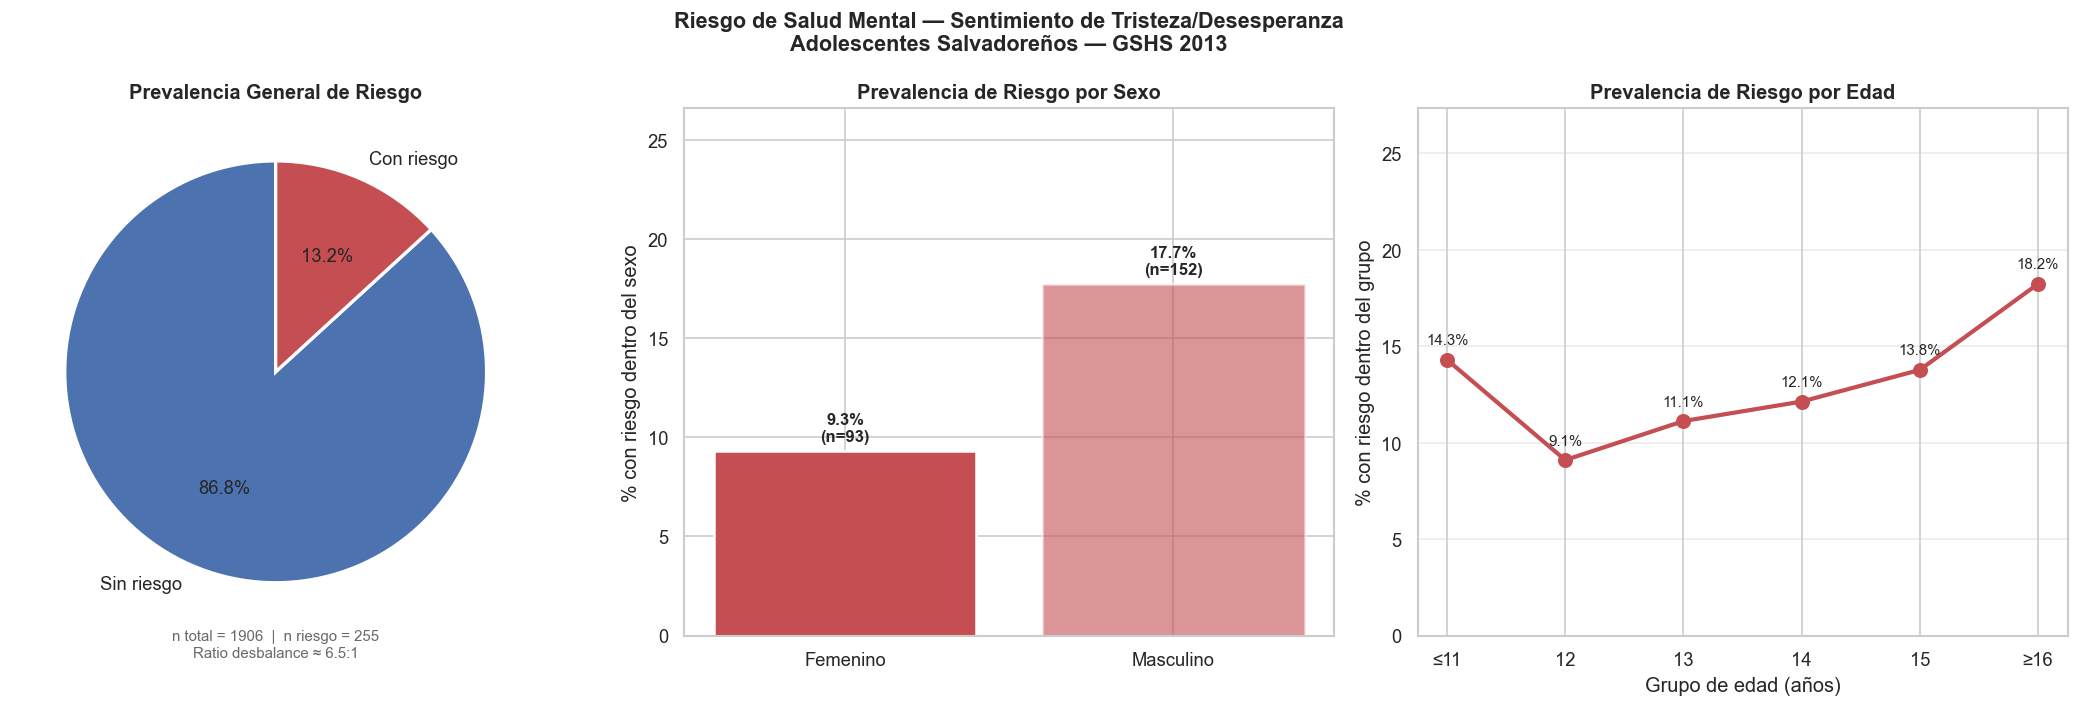

In [16]:
# ── Recodificación correcta de QN26 ──────────────────────────────────────────
# QN26 = 2 → Q26=1 "Nunca" → Sin riesgo → 0
# QN26 = 1 → Q26=2,3,4,5  → Con riesgo → 1
df_clean["Riesgo_SM"] = df_clean["QN26"].map({2.0: 0, 1.0: 1})

# Verificación
conteo   = df_clean["Riesgo_SM"].value_counts(dropna=False)
n_valido = df_clean["Riesgo_SM"].notna().sum()
n_riesgo = int(df_clean["Riesgo_SM"].sum())
n_sin    = n_valido - n_riesgo
ratio    = n_sin / n_riesgo if n_riesgo > 0 else 0

print("═" * 50)
print("  VERIFICACIÓN FINAL Riesgo_SM")
print("═" * 50)
print(conteo.to_string())
print(f"\n  Sin riesgo (0): {n_sin:>4}  ({n_sin/n_valido*100:.1f}%)")
print(f"  Con riesgo (1): {n_riesgo:>4}  ({n_riesgo/n_valido*100:.1f}%)")
print(f"  Ratio desbalance: {ratio:.1f}:1")
print(f"  → SMOTE confirmado para Fase 5")

# ── EDA Visual final corregido ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Riesgo de Salud Mental — Sentimiento de Tristeza/Desesperanza\n"
             "Adolescentes Salvadoreños — GSHS 2013",
             fontsize=13, fontweight="bold")

df_sm = df_clean[["Riesgo_SM", "Q2", "Q1"]].dropna()
df_sm["Riesgo"] = df_sm["Riesgo_SM"].map({1: "Con riesgo", 0: "Sin riesgo"})
df_sm["Sexo"]   = df_sm["Q2"].map({1.0: "Femenino", 2.0: "Masculino"})
edad_labels     = {1.0: "≤11", 2.0: "12", 3.0: "13",
                   4.0: "14",  5.0: "15", 6.0: "≥16"}
df_sm["Edad"]   = df_sm["Q1"].map(edad_labels)
orden_edad      = ["≤11", "12", "13", "14", "15", "≥16"]
colores_riesgo  = {"Con riesgo": "#C44E52", "Sin riesgo": "#4C72B0"}

# ── Panel 1: Prevalencia general ─────────────────────────────────────────────
ax1 = axes[0]
conteo_plot = df_sm["Riesgo"].value_counts()
ax1.pie(
    conteo_plot.values,
    labels=conteo_plot.index,
    autopct="%1.1f%%",
    colors=[colores_riesgo[l] for l in conteo_plot.index],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11}
)
ax1.set_title("Prevalencia General de Riesgo", fontweight="bold")
ax1.text(0, -1.35,
         f"n total = {n_valido}  |  n riesgo = {n_riesgo}\n"
         f"Ratio desbalance ≈ {ratio:.1f}:1",
         ha="center", fontsize=9, color="dimgray")

# ── Panel 2: Riesgo por sexo ──────────────────────────────────────────────────
ax2 = axes[1]
tabla_sexo = (df_sm.groupby(["Sexo", "Riesgo"])
                   .size()
                   .reset_index(name="n"))
tabla_sexo["pct"] = tabla_sexo.groupby("Sexo")["n"].transform(
    lambda x: x / x.sum() * 100
)
riesgo_sexo = tabla_sexo[tabla_sexo["Riesgo"] == "Con riesgo"].reset_index(drop=True)

alphas = [1.0, 0.6]
for i, row in riesgo_sexo.iterrows():
    ax2.bar(row["Sexo"], row["pct"],
            color=colores_riesgo["Con riesgo"],
            alpha=alphas[i], edgecolor="white", linewidth=1.5)
    ax2.text(i, row["pct"] + 0.5,
             f"{row['pct']:.1f}%\n(n={int(row['n'])})",
             ha="center", fontsize=10, fontweight="bold")

ax2.set_title("Prevalencia de Riesgo por Sexo", fontweight="bold")
ax2.set_ylabel("% con riesgo dentro del sexo")
ax2.set_ylim(0, riesgo_sexo["pct"].max() * 1.5)
ax2.set_xlabel("")

# ── Panel 3: Riesgo por grupo de edad ────────────────────────────────────────
ax3 = axes[2]
tabla_edad = (df_sm.groupby(["Edad", "Riesgo"])
                   .size()
                   .reset_index(name="n"))
tabla_edad["pct"] = tabla_edad.groupby("Edad")["n"].transform(
    lambda x: x / x.sum() * 100
)
riesgo_edad = (tabla_edad[tabla_edad["Riesgo"] == "Con riesgo"]
               .set_index("Edad")
               .reindex(orden_edad)
               .reset_index())

ax3.plot(riesgo_edad["Edad"], riesgo_edad["pct"],
         marker="o", linewidth=2.5, markersize=8,
         color=colores_riesgo["Con riesgo"])
for _, row in riesgo_edad.iterrows():
    if pd.notna(row["pct"]):
        ax3.text(row["Edad"], row["pct"] + 0.8,
                 f"{row['pct']:.1f}%", ha="center", fontsize=9)

ax3.set_title("Prevalencia de Riesgo por Edad", fontweight="bold")
ax3.set_xlabel("Grupo de edad (años)")
ax3.set_ylabel("% con riesgo dentro del grupo")
ax3.set_ylim(0, riesgo_edad["pct"].max() * 1.5)
ax3.grid(axis="y", alpha=0.4)

plt.tight_layout()
fig.savefig(FIG_PATH / "04_riesgo_salud_mental.png", bbox_inches="tight", dpi=150)
plt.show()

---
## Cierre de Fase 2 — Guardado del dataset procesado

Con el EDA completo y el target correctamente codificado, guardamos
`df_clean` en `data/processed/` para que las fases siguientes partan
de datos ya auditados y limpios.

### Resumen de decisiones tomadas en esta fase

| Decisión | Justificación |
|----------|---------------|
| Reemplazar `1.79e+308` por `NaN` | Marcador de nulos SPSS |
| Eliminar 12 columnas con >60% nulos | No imputables sin introducir ruido |
| Eliminar Q4 y Q5 | Prevenir data leakage en Tarea A |
| Eliminar stratum y psu | Variables de diseño muestral sin valor predictivo |
| Crear columna `IMC` desde df original | Target Tarea A, filtrado a rango 10-60 OMS |
| Crear columna `Riesgo_SM` desde QN26 | Target Tarea B, codificación 0/1 corregida |

### Estado del dataset procesado
- **Filas:** 1,915  
- **Columnas:** 90 (88 originales + IMC + Riesgo_SM)  
- **NaN restantes:** serán imputados en Fase 3 (Feature Engineering)

In [17]:
# ── Guardado del dataset procesado ───────────────────────────────────────────
PROC_PATH.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(PROC_PATH, index=False)

# Verificación de integridad del archivo guardado
df_verify = pd.read_csv(PROC_PATH)

print("═" * 55)
print("  DATASET PROCESADO — VERIFICACIÓN DE INTEGRIDAD")
print("═" * 55)
print(f"  Archivo  : {PROC_PATH}")
print(f"  Filas    : {df_verify.shape[0]}")
print(f"  Columnas : {df_verify.shape[1]}")
print(f"  Tamaño   : {PROC_PATH.stat().st_size / 1024:.1f} KB")
print("─" * 55)
print(f"  Columnas nuevas presentes:")
print(f"    IMC       — min:{df_verify['IMC'].min():.2f}  "
      f"max:{df_verify['IMC'].max():.2f}  "
      f"NaN:{df_verify['IMC'].isna().sum()}")
print(f"    Riesgo_SM — valores: "
      f"{sorted(df_verify['Riesgo_SM'].dropna().unique().tolist())}"
      f"  NaN:{df_verify['Riesgo_SM'].isna().sum()}")
print("─" * 55)

# Resumen global de NaN restantes para Fase 3
nan_resumen = df_verify.isna().sum()
nan_resumen = nan_resumen[nan_resumen > 0].sort_values(ascending=False)
print(f"\n  Columnas con NaN pendientes de imputar en Fase 3: "
      f"{len(nan_resumen)}")
print(f"  Total celdas NaN restantes: {nan_resumen.sum():,}")
print("\n  Top 10 columnas con más NaN:")
print(nan_resumen.head(10).to_string())
print("═" * 55)
print("\n✅ Fase 2 completada. Dataset guardado en data/processed/")

═══════════════════════════════════════════════════════
  DATASET PROCESADO — VERIFICACIÓN DE INTEGRIDAD
═══════════════════════════════════════════════════════
  Archivo  : ../data/processed/slv2013_clean.csv
  Filas    : 1915
  Columnas : 90
  Tamaño   : 695.1 KB
───────────────────────────────────────────────────────
  Columnas nuevas presentes:
    IMC       — min:13.79  max:46.78  NaN:177
    Riesgo_SM — valores: [0.0, 1.0]  NaN:9
───────────────────────────────────────────────────────

  Columnas con NaN pendientes de imputar en Fase 3: 89
  Total celdas NaN restantes: 4,217

  Top 10 columnas con más NaN:
Q17         201
QN17        201
qnowtg      177
qnunwtg     177
IMC         177
qnobeseg    177
Q19         174
Q34         155
Q18         116
Q44          98
═══════════════════════════════════════════════════════

✅ Fase 2 completada. Dataset guardado en data/processed/
